# Листок 2. Комплексные числа
Каждый пункт решается Python-кодом; после условия кратко описаны шаги вычисления.

## 2.1
**Условие.** Представить три выражения в алгебраической, тригонометрической и показательной формах.
**Код.** Каждое число выводится в алгебраической, тригонометрической и показательной формах вместе с модулем и главным аргументом. Результаты: a=10−11i, b=2, c=−64.

In [13]:
import sympy as sp

imaginary_unit = sp.I
expressions = [
    (5 + imaginary_unit) * (7 - 6 * imaginary_unit) / (3 + imaginary_unit),
    (1 + imaginary_unit) ** 5 / (1 - imaginary_unit) ** 3,
    (
        (-1 + imaginary_unit * sp.sqrt(3)) ** 15
        / (1 - imaginary_unit) ** 20
        + (-1 - imaginary_unit * sp.sqrt(3)) ** 15
        / (1 + imaginary_unit) ** 20
    ),
]

for name, expression in zip("abc", expressions):
    value = sp.simplify(expression)
    modulus = sp.Abs(value)
    argument = sp.arg(value)

    print(f"{name}) Алгебраическая форма: {value}")
    print(f"   Модуль: {modulus}")
    print(f"   Arg: {argument} ≈ {float(argument):.6f} рад")
    print(
        f"   Тригонометрическая форма: "
        f"{modulus} · (cos({argument}) + i sin({argument}))"
    )
    print(f"   Показательная форма: {modulus} · exp(i · ({argument}))")
    print()

a) Алгебраическая форма: 10 - 11*I
   Модуль: sqrt(221)
   Arg: -atan(11/10) ≈ -0.832981 рад
   Тригонометрическая форма: sqrt(221) · (cos(-atan(11/10)) + i sin(-atan(11/10)))
   Показательная форма: sqrt(221) · exp(i · (-atan(11/10)))

b) Алгебраическая форма: 2
   Модуль: 2
   Arg: 0 ≈ 0.000000 рад
   Тригонометрическая форма: 2 · (cos(0) + i sin(0))
   Показательная форма: 2 · exp(i · (0))

c) Алгебраическая форма: -64
   Модуль: 64
   Arg: pi ≈ 3.141593 рад
   Тригонометрическая форма: 64 · (cos(pi) + i sin(pi))
   Показательная форма: 64 · exp(i · (pi))



## 2.2
**Условие.** Решить z⁸=1+i и изобразить решения.
**Код.** Корни вычисляются по формуле Муавра. Таблица показывает их координаты, а номера на графике соответствуют строкам таблицы: zₖ=2^(1/16) exp(i(π/32+kπ/4)), k=0,…,7.

Решения уравнения z⁸ = 1 + i
Формула: zₖ = 2^(1/16) · exp(i(π/32 + kπ/4)), k = 0, …, 7

 k       Re zₖ       Im zₖ
 0     1.039245     0.102357
 1     0.662480     0.807235
 2    -0.102357     1.039245
 3    -0.807235     0.662480
 4    -1.039245    -0.102357
 5    -0.662480    -0.807235
 6     0.102357    -1.039245
 7     0.807235    -0.662480


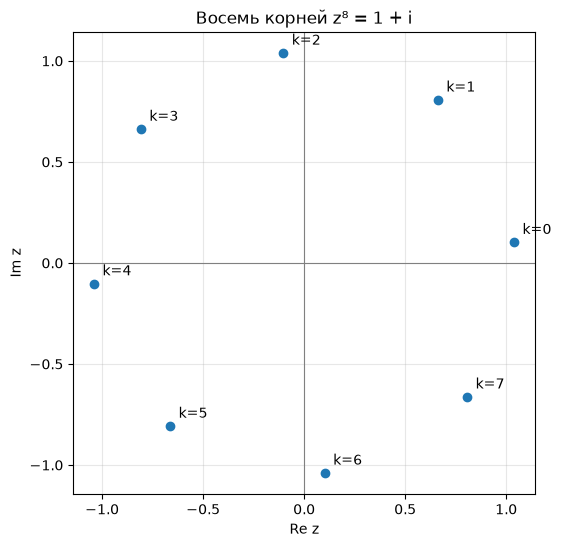

In [14]:
import numpy as np
import matplotlib.pyplot as plt

number = 1 + 1j
modulus = abs(number)
argument = np.angle(number)
root_count = 8

roots = np.array([
    modulus ** (1 / root_count)
    * np.exp(1j * (argument + 2 * np.pi * index) / root_count)
    for index in range(root_count)
])

print("Решения уравнения z⁸ = 1 + i")
print("Формула: zₖ = 2^(1/16) · exp(i(π/32 + kπ/4)), k = 0, …, 7")
print()
print(" k       Re zₖ       Im zₖ")
for index, root in enumerate(roots):
    print(f"{index:2d}   {root.real:10.6f}   {root.imag:10.6f}")

figure, axis = plt.subplots(figsize=(6, 6))
axis.scatter(roots.real, roots.imag, color="tab:blue", zorder=3)
for index, root in enumerate(roots):
    axis.annotate(
        f"k={index}",
        (root.real, root.imag),
        xytext=(6, 6),
        textcoords="offset points",
    )

axis.axhline(0, color="gray", linewidth=0.8)
axis.axvline(0, color="gray", linewidth=0.8)
axis.set(xlabel="Re z", ylabel="Im z", title="Восемь корней z⁸ = 1 + i")
axis.set_aspect("equal")
axis.grid(alpha=0.3)
plt.show()

## 2.3
**Условие.** Вычислить и изобразить все корни: ⁸√1, ⁴√(−18/(1+i√3)), ³√((1−5i)/(1+i)−(51+2i)/(2−i)+11), ⁹√(1−i).
**Код.** Функция `complex_roots` вычисляет корни по формуле Муавра: модуль возводится в степень 1/n, а к аргументу прибавляется 2πk перед делением на n. Для четырёх чисел задаются степени корней, затем все наборы изображаются на комплексной плоскости.

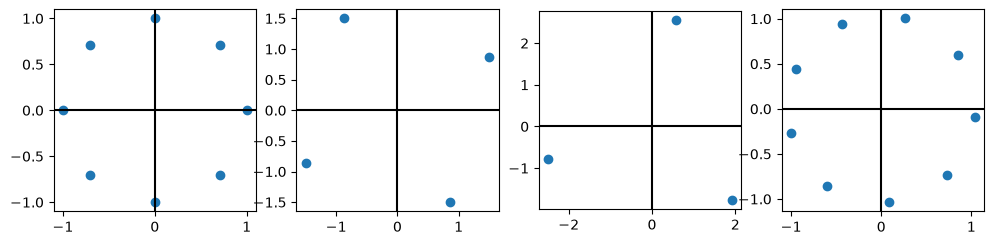

In [15]:
import numpy as np
import matplotlib.pyplot as plt


def complex_roots(number, degree):
    modulus = abs(number)
    argument = np.angle(number)
    return np.array([
        modulus ** (1 / degree)
        * np.exp(1j * (argument + 2 * np.pi * index) / degree)
        for index in range(degree)
    ])


numbers_and_degrees = [
    (1, 8),
    (-18 / (1 + 1j * np.sqrt(3)), 4),
    ((1 - 5j) / (1 + 1j) - (51 + 2j) / (2 - 1j) + 11, 3),
    (1 - 1j, 9),
]
root_sets = [
    complex_roots(number, degree)
    for number, degree in numbers_and_degrees
]

figure, axes = plt.subplots(1, 4, figsize=(12, 3))
for axis, roots in zip(axes, root_sets):
    axis.scatter(roots.real, roots.imag)
    axis.axhline(0, color="k")
    axis.axvline(0, color="k")
    axis.set_aspect("equal")

plt.show()

## 2.4
**Условие.** Изобразить шесть множеств, заданных модулями, действительной частью и аргументами.
**Код.** На сетке комплексных точек условия задаются булевыми масками; `np.angle` вычисляет главный аргумент. Каждая маска изображается отдельно. Для а получается внутренняя область эллипса x²/3+y²/4<1; б — полуплоскость x+y<√2; в — одна точка 0. Для г–е–ж код напрямую отображает заданные аргументные области.

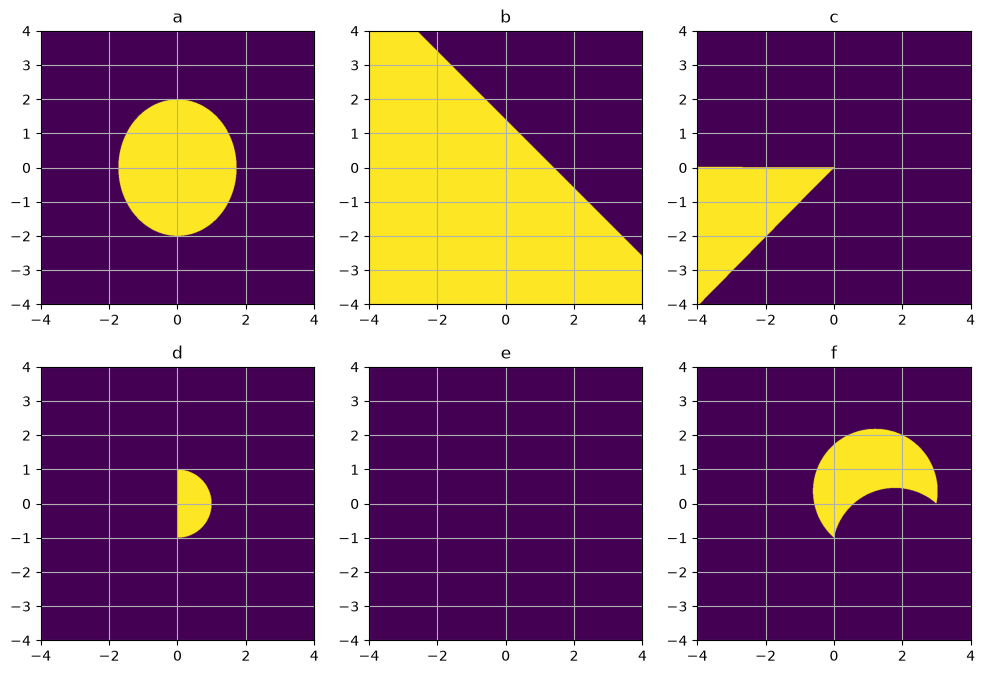

In [16]:
import numpy as np
import matplotlib.pyplot as plt

coordinates = np.linspace(-4, 4, 700)
real_part, imaginary_part = np.meshgrid(coordinates, coordinates)
z = real_part + 1j * imaginary_part

ellipse = abs(z - 1j) + abs(z + 1j) < 4
half_plane = np.real(z * (1 - 1j)) < np.sqrt(2)

# Численный допуск помогает показать линии на дискретной сетке.
tolerance = 0.012
equal_distances = (
    (abs(z + 1) - abs(z + 1j) < tolerance)
    & (abs(z + 1j) - abs(z - 1j) < tolerance)
)

first_angle = np.angle((1j - z) / (z + 1j))
first_sector = (first_angle > 0) & (first_angle < np.pi / 2)

second_angle = np.angle((2 - 1j * z) / (z + 3j))
second_sector = (
    (second_angle >= -2 * np.pi / 3)
    & (second_angle <= -5 * np.pi / 6)
)

third_angle = np.angle((3 - z) / (z + 1j))
third_sector = (
    (third_angle >= -2 * np.pi / 3)
    & (third_angle <= -np.pi / 3)
)

regions = [
    ellipse,
    half_plane,
    equal_distances,
    first_sector,
    second_sector,
    third_sector,
]
figure, axes = plt.subplots(2, 3, figsize=(12, 8))

for axis, region, title in zip(axes.flat, regions, "abcdef"):
    axis.imshow(region, extent=[-4, 4, -4, 4], origin="lower")
    axis.set_title(title)
    axis.grid()

plt.show()

## 2.5
**Условие.** Доказать, что A|z|²+Bz+conj(B)conj(z)+C=0 при A>0, AC<|B|² — окружность; найти центр и радиус.
**Код.** После выделения полного квадрата центр равен −conj(B)/A, радиус — √(|B|²−AC)/A. Для примера A=2, B=3−4i, C=5 получаются центр −1.5−2i и радиус √15/2≈1.936492.

In [17]:
import numpy as np

quadratic_coefficient = 2
linear_coefficient = 3 - 4j
constant = 5

center = -np.conj(linear_coefficient) / quadratic_coefficient
radius_squared = (
    abs(linear_coefficient) ** 2
    - quadratic_coefficient * constant
) / quadratic_coefficient**2
radius = np.sqrt(radius_squared)

print("A|z|² + Bz + B̄z̄ + C = 0 — окружность при A > 0 и AC < |B|²")
print("Центр: z₀ = −conj(B) / A")
print("Радиус: R = √(|B|² − AC) / A")
print()
print(f"Для A={quadratic_coefficient}, B={linear_coefficient}, C={constant}:")
print(f"  z₀ = {center.real:.3f} {center.imag:+.3f}i")
print(f"  R² = {radius_squared:.4f}")
print(f"  R  = {radius:.6f}")

A|z|² + Bz + B̄z̄ + C = 0 — окружность при A > 0 и AC < |B|²
Центр: z₀ = −conj(B) / A
Радиус: R = √(|B|² − AC) / A

Для A=2, B=(3-4j), C=5:
  z₀ = -1.500 -2.000i
  R² = 3.7500
  R  = 1.936492


## 2.6
**Условие.** Найти 11 корней p(x)=x¹¹+x¹⁰+x⁸−2x⁷−x⁵+x⁴+2x²+2x+2 и указать сумму их модулей и максимальную действительную часть.
**Код.** `np.roots` находит корни; таблица содержит их действительные и мнимые части. Ниже выводятся сумма модулей ≈11.973384 и максимальная действительная часть ≈1.080602. Номера на графике совпадают с номерами в таблице.

Найдено корней: 11
 №        Re z         Im z
 1     -1.776769      0.000000
 2     -0.707434     -0.464375
 3     -0.707434      0.464375
 4     -0.450037     -0.803923
 5     -0.450037      0.803923
 6     -0.012500     -1.182699
 7     -0.012500      1.182699
 8      0.477755     -0.901075
 9      0.477755      0.901075
10      1.080602     -0.323893
11      1.080602      0.323893

Сумма модулей: 11.973384
Максимальная действительная часть: 1.080602


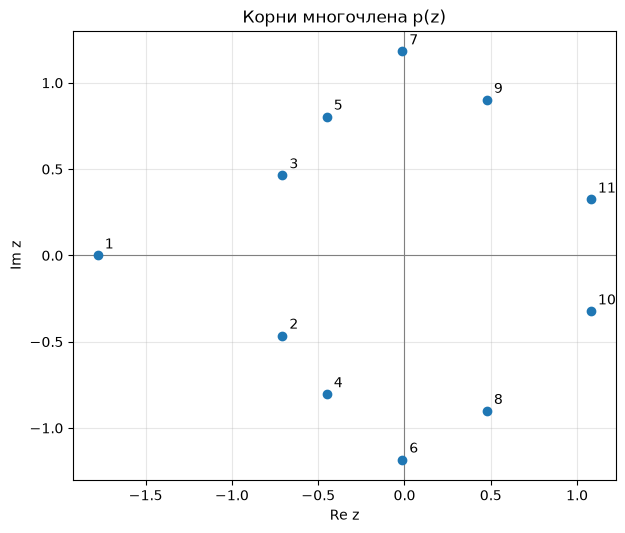

In [18]:
import numpy as np
import matplotlib.pyplot as plt

coefficients = [1, 1, 0, 1, -2, 0, -1, 1, 0, 2, 2, 2]
roots = np.roots(coefficients)
ordered_roots = sorted(roots, key=lambda root: (root.real, root.imag))

modulus_sum = np.sum(np.abs(roots))
largest_real_part = np.max(roots.real)

print(f"Найдено корней: {len(roots)}")
print(" №        Re z         Im z")
for index, root in enumerate(ordered_roots, start=1):
    print(f"{index:2d}   {root.real:11.6f}   {root.imag:11.6f}")

print()
print(f"Сумма модулей: {modulus_sum:.6f}")
print(f"Максимальная действительная часть: {largest_real_part:.6f}")

figure, axis = plt.subplots(figsize=(7, 6))
axis.scatter(roots.real, roots.imag, color="tab:blue", zorder=3)
for index, root in enumerate(ordered_roots, start=1):
    axis.annotate(
        str(index),
        (root.real, root.imag),
        xytext=(5, 5),
        textcoords="offset points",
    )

axis.axhline(0, color="gray", linewidth=0.8)
axis.axvline(0, color="gray", linewidth=0.8)
axis.set(xlabel="Re z", ylabel="Im z", title="Корни многочлена p(z)")
axis.set_aspect("equal")
axis.grid(alpha=0.3)
plt.show()

## 2.7
**Условие.** Вычислить $\binom{1+i}{1-i}$, найти его главный аргумент и построить линии уровня $\operatorname{Arg}\binom{z}{1}$.
**Код.** По формуле через гамма-функцию C_(1+i)^(1−i)≈4.36745+4.85163i и Arg≈0.837869 рад. Для второй части C_z^1=Γ(z+1)/(Γ(2)Γ(z))=z, поэтому Arg(C_z^1)=Arg z, кроме точки z=0, где аргумент не определён. Линии уровня — лучи из начала координат; скачок цвета на отрицательной действительной полуоси связан с выбором главного аргумента. 

Обобщённый биномиальный коэффициент C_(1+i)^(1−i):
  C = 4.367449 +4.851630i
  Arg C = 0.837869 рад = 48.006°

Для второй части C_z^1 = z, поэтому Arg(C_z^1) = Arg z.
Его линии уровня — лучи из начала координат.


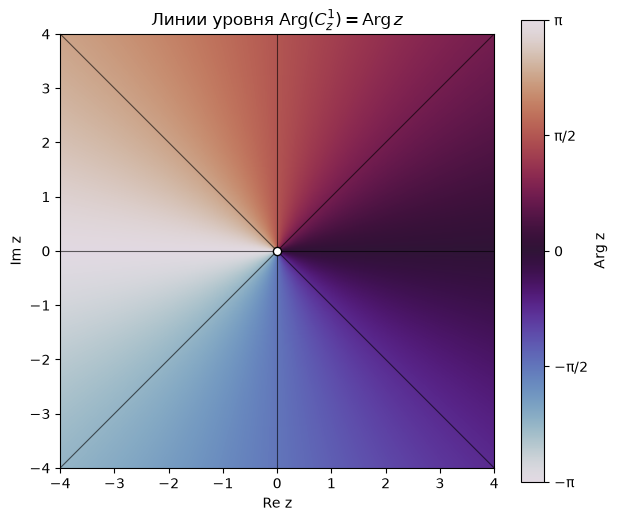

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

upper_index = 1 + 1j
lower_index = 1 - 1j
binomial_value = gamma(upper_index + 1) / (
    gamma(lower_index + 1)
    * gamma(upper_index - lower_index + 1)
)
principal_argument = np.angle(binomial_value)

print("Обобщённый биномиальный коэффициент C_(1+i)^(1−i):")
print(
    f"  C = {binomial_value.real:.6f} "
    f"{binomial_value.imag:+.6f}i"
)
print(
    f"  Arg C = {principal_argument:.6f} рад "
    f"= {np.degrees(principal_argument):.3f}°"
)
print()
print("Для второй части C_z^1 = z, поэтому Arg(C_z^1) = Arg z.")
print("Его линии уровня — лучи из начала координат.")

coordinates = np.linspace(-4, 4, 401)
real_part, imaginary_part = np.meshgrid(coordinates, coordinates)
phase = np.angle(real_part + 1j * imaginary_part)
origin = len(coordinates) // 2
phase[origin, origin] = np.nan  # В нуле Arg не определён.

figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(
    phase,
    extent=(-4, 4, -4, 4),
    origin="lower",
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi,
)

ray_length = np.linspace(0, 6, 200)
level_angles = np.arange(-3, 5) * np.pi / 4
for angle in level_angles:
    axis.plot(
        ray_length * np.cos(angle),
        ray_length * np.sin(angle),
        color="black",
        linewidth=0.8,
        alpha=0.6,
    )

axis.scatter(0, 0, s=35, facecolor="white", edgecolor="black", zorder=5)
axis.set(
    xlim=(-4, 4),
    ylim=(-4, 4),
    xlabel="Re z",
    ylabel="Im z",
    title=r"Линии уровня $\mathrm{Arg}(C_z^1)=\mathrm{Arg}\,z$",
)
axis.set_aspect("equal")
colorbar = figure.colorbar(image, ax=axis, label="Arg z")
colorbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
colorbar.set_ticklabels(["−π", "−π/2", "0", "π/2", "π"])
plt.show()

## 2.8
**Условие.** λ — корень 14-й степени из 1 с Im λ>0 и максимальным Re λ; найти det(A+λI), A=[[7,5],[6,2]].
**Код.** Из корней четырнадцатой степени с положительной мнимой частью максимальную действительную часть имеет λ=e^(iπ/7). Далее det(A+λI)=λ²+9λ−16≈−7.267790+4.686785i. Код выводит формулу и численные действительную и мнимую части.

In [20]:
import numpy as np

parameter = np.exp(1j * np.pi / 7)
matrix = np.array([[7, 5], [6, 2]], dtype=complex)
determinant = np.linalg.det(matrix + parameter * np.eye(2))

print("Корень: λ = exp(iπ/7) = cos(π/7) + i sin(π/7)")
print("Определитель: det(A + λI) = (7 + λ)(2 + λ) − 30")
print("                        = λ² + 9λ − 16")
print()
print(
    f"Численно: det(A + λI) = {determinant.real:.6f} "
    f"{determinant.imag:+.6f}i"
)
print(f"Re = {determinant.real:.6f}")
print(f"Im = {determinant.imag:.6f}")

Корень: λ = exp(iπ/7) = cos(π/7) + i sin(π/7)
Определитель: det(A + λI) = (7 + λ)(2 + λ) − 30
                        = λ² + 9λ − 16

Численно: det(A + λI) = -7.267790 +4.686785i
Re = -7.267790
Im = 4.686785


## 2.9
**Условие.** Сгенерировать множества Жюлиа для z²+c при двух c и для двух данных рациональных отображений.
**Код.** Функция `julia_set` создаёт сетку, итерирует отображение до выхода за радиус 10 и возвращает число итераций. Для четырёх отображений строятся изображения. Большое число итераций означает точку, близкую к заполненному множеству Жюлиа.

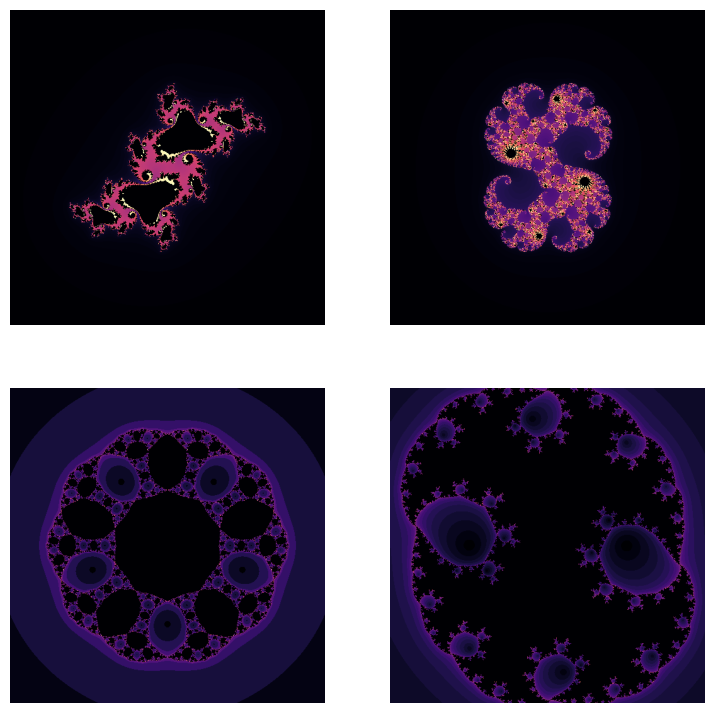

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def julia_set(function, grid_size=500, iterations=150):
    coordinates = np.linspace(-2, 2, grid_size)
    points = np.add.outer(1j * coordinates, coordinates)
    escape_steps = np.zeros(points.shape)
    active = np.ones(points.shape, dtype=bool)

    for step in range(iterations):
        points[active] = function(points[active])
        escaped = abs(points) > 10
        escape_steps[active & escaped] = step
        active &= ~escaped

    return escape_steps


functions = [
    lambda z: z**2 + (-0.1 + 0.65j),
    lambda z: z**2 + (0.28 + 0.009j),
    lambda z: (1j * z**5 - 1) / (z**5 - 1j),
    lambda z: (z**2 + 1j) / (1 - z**2),
]

figure, axes = plt.subplots(2, 2, figsize=(9, 9))
for axis, function in zip(axes.flat, functions):
    axis.imshow(julia_set(function), cmap="magma", extent=[-2, 2, -2, 2])
    axis.axis("off")

plt.show()

## 2.10
**Условие.** Изобразить на сфере Римана прямую, окружность, параболу, гиперболу и логарифмическую спираль.
**Код.** Функция `stereographic_projection` переводит комплексные точки на единичную сферу. После задания пяти кривых строится поверхность сферы, а на ней — образы кривых. Логарифмическая спираль задаётся r=a exp(bφ).

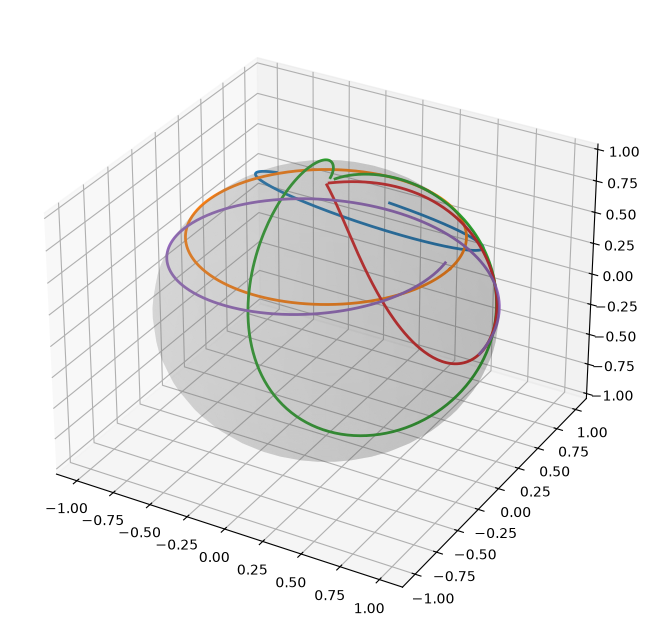

In [22]:
import numpy as np
import matplotlib.pyplot as plt


def stereographic_projection(z):
    squared_modulus = z.real**2 + z.imag**2
    denominator = 1 + squared_modulus
    return (
        2 * z.real / denominator,
        2 * z.imag / denominator,
        (squared_modulus - 1) / denominator,
    )


line_parameter = np.linspace(-5, 5, 500)
angle_parameter = np.linspace(0, 2 * np.pi, 500)
curves = [
    line_parameter + 1j,
    2 * np.exp(1j * angle_parameter),
    line_parameter + 1j * line_parameter**2,
    np.cosh(line_parameter) + 1j * np.sinh(line_parameter),
    np.exp(0.12 * angle_parameter) * np.exp(1j * angle_parameter),
]

polar_angles = np.linspace(0, np.pi, 40)
azimuthal_angles = np.linspace(0, 2 * np.pi, 40)
polar_grid, azimuthal_grid = np.meshgrid(polar_angles, azimuthal_angles)

figure = plt.figure(figsize=(10, 8))
axis = figure.add_subplot(projection="3d")
axis.plot_surface(
    np.sin(polar_grid) * np.cos(azimuthal_grid),
    np.sin(polar_grid) * np.sin(azimuthal_grid),
    np.cos(polar_grid),
    alpha=0.15,
    color="gray",
)

for curve in curves:
    axis.plot(*stereographic_projection(curve), lw=2)

plt.show()